# Exploratory Data Analysis of OBD-II Time Series

Goal: analyze sensor behavior, temporal dynamics, and cross-signal interactions to justify downstream feature engineering and modeling choices.

## 1. Basic Data Overview

Inspect dataset shape, schema, quality, and descriptive statistics before behavior-focused analysis.

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
plt.style.use("seaborn-v0_8")

In [3]:
data_path = Path("../data/processed/clean_obd_data.csv")

df = pd.read_csv(data_path)

df.head()

,trip_id,time,gap_flag,speed,rpm,throttle,map,maf,pedal_d,coolant_temp,intake_temp,ambient_temp
0,1,0.000,0,0.0,0.0,89.0,96.0,0.91,14.1,31.0,22.0,21.0
1,1,0.091,0,0.0,0.0,89.0,96.0,0.91,14.1,31.0,22.0,21.0
2,1,0.181,0,0.0,0.0,89.0,96.0,0.91,14.1,31.0,22.0,21.0
3,1,0.272,0,0.0,0.0,89.0,96.0,0.91,14.1,31.0,22.0,21.0
4,1,0.370,0,0.0,0.0,89.0,96.0,0.91,14.1,31.0,22.0,21.0


In [4]:
df.shape

(2693824, 12)

In [5]:
df.columns

Index(['trip_id', 'time', 'gap_flag', 'speed', 'rpm', 'throttle', 'map', 'maf',
       'pedal_d', 'coolant_temp', 'intake_temp', 'ambient_temp'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2693824 entries, 0 to 2693823
Data columns (total 12 columns):
 #   Column        Dtype  
---  ------        -----  
 0   trip_id       int64  
 1   time          float64
 2   gap_flag      int64  
 3   speed         float64
 4   rpm           float64
 5   throttle      float64
 6   map           float64
 7   maf           float64
 8   pedal_d       float64
 9   coolant_temp  float64
 10  intake_temp   float64
 11  ambient_temp  float64
dtypes: float64(10), int64(2)
memory usage: 246.6 MB


In [7]:
df.isnull().sum().sort_values(ascending=False)

trip_id         0
time            0
gap_flag        0
speed           0
rpm             0
throttle        0
map             0
maf             0
pedal_d         0
coolant_temp    0
intake_temp     0
ambient_temp    0
dtype: int64

In [8]:
df.describe()

,trip_id,time,gap_flag,speed,rpm,throttle,map,maf,pedal_d,coolant_temp,intake_temp,ambient_temp
count,2.693824e+06,2.693824e+06,2.693824e+06,2.693824e+06,2.693824e+06,2.693824e+06,2.693824e+06,2.693824e+06,2.693824e+06,2.693824e+06,2.693824e+06,2.693824e+06
mean,4.227729e+01,1.939601e+03,4.838475e-03,6.224243e+01,1.494567e+03,8.124807e+01,1.253363e+02,2.270087e+01,2.159211e+01,8.153735e+01,1.919079e+01,1.022123e+01
std,2.437440e+01,1.452057e+03,6.939068e-02,4.578801e+01,5.351184e+02,1.131040e+01,3.139587e+01,1.636235e+01,1.264071e+01,1.809259e+01,1.807669e+01,1.125986e+01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.370000e+01,3.600000e+01,0.000000e+00,1.410000e+01,-1.000000e+00,-4.000000e+01,-1.400000e+01
25%,2.100000e+01,7.757075e+02,0.000000e+00,1.900000e+01,1.108000e+03,8.350000e+01,1.040000e+02,1.163000e+01,1.410000e+01,8.600000e+01,7.000000e+00,0.000000e+00
50%,4.200000e+01,1.679904e+03,0.000000e+00,6.000000e+01,1.539000e+03,8.350000e+01,1.140000e+02,1.861000e+01,1.410000e+01,9.000000e+01,1.800000e+01,1.300000e+01
75%,6.400000e+01,2.778785e+03,0.000000e+00,1.020000e+02,1.851000e+03,8.350000e+01,1.370000e+02,2.913000e+01,2.670000e+01,9.100000e+01,2.800000e+01,2.000000e+01
max,8.100000e+01,8.083974e+03,1.000000e+00,2.000000e+02,4.315000e+03,8.900000e+01,2.470000e+02,1.292200e+02,8.510000e+01,1.030000e+02,1.000000e+02,3.300000e+01


## 2. Distribution Analysis

Understand marginal distributions of key OBD signals and their operating ranges.

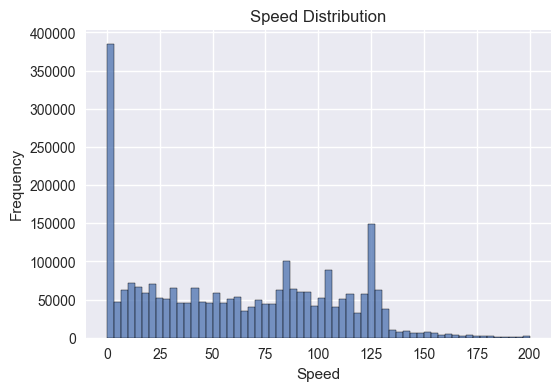

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df["speed"], bins=60)
plt.title("Speed Distribution")
plt.xlabel("Speed")
plt.ylabel("Frequency")
plt.show()

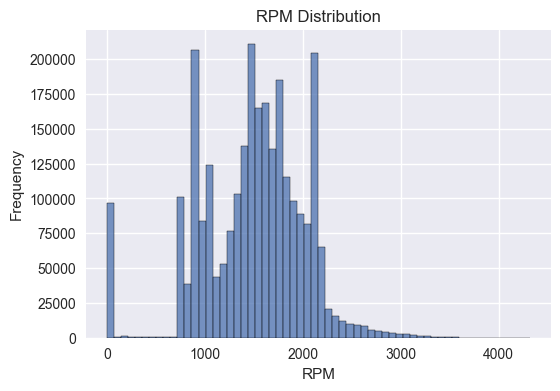

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df["rpm"], bins=60)
plt.title("RPM Distribution")
plt.xlabel("RPM")
plt.ylabel("Frequency")
plt.show()

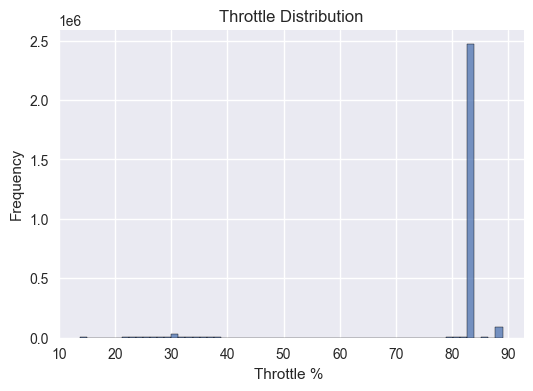

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df["throttle"], bins=60)
plt.title("Throttle Distribution")
plt.xlabel("Throttle % ")
plt.ylabel("Frequency")
plt.show()

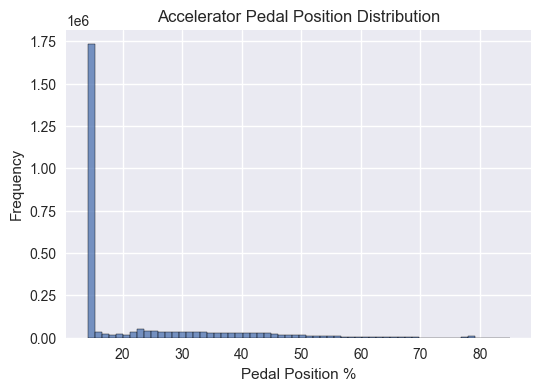

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df["pedal_d"], bins=60)
plt.title("Accelerator Pedal Position Distribution")
plt.xlabel("Pedal Position %")
plt.ylabel("Frequency")
plt.show()

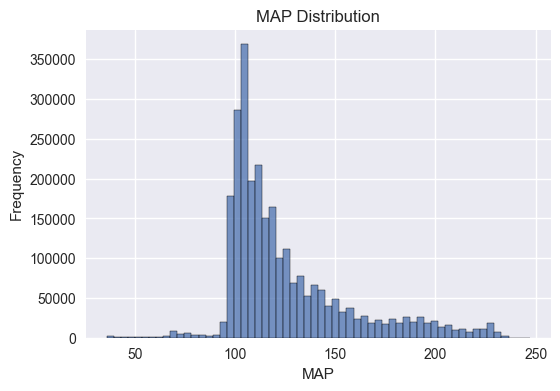

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df["map"], bins=60)
plt.title("MAP Distribution")
plt.xlabel("MAP")
plt.ylabel("Frequency")
plt.show()

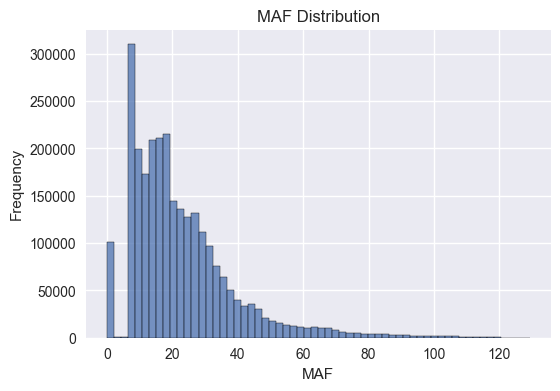

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df["maf"], bins=60)
plt.title("MAF Distribution")
plt.xlabel("MAF")
plt.ylabel("Frequency")
plt.show()

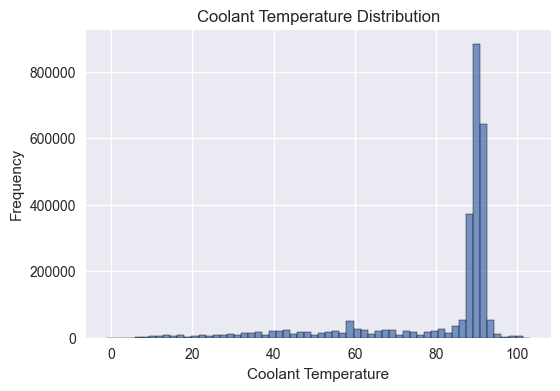

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df["coolant_temp"], bins=60)
plt.title("Coolant Temperature Distribution")
plt.xlabel("Coolant Temperature")
plt.ylabel("Frequency")
plt.show()

## 3. Time-Series Inspection

Visualize temporal trajectories for a sample trip to inspect nonstationary behavior.

In [16]:
trip_id = df["trip_id"].unique()[0]

sample_trip = df[df["trip_id"] == trip_id]

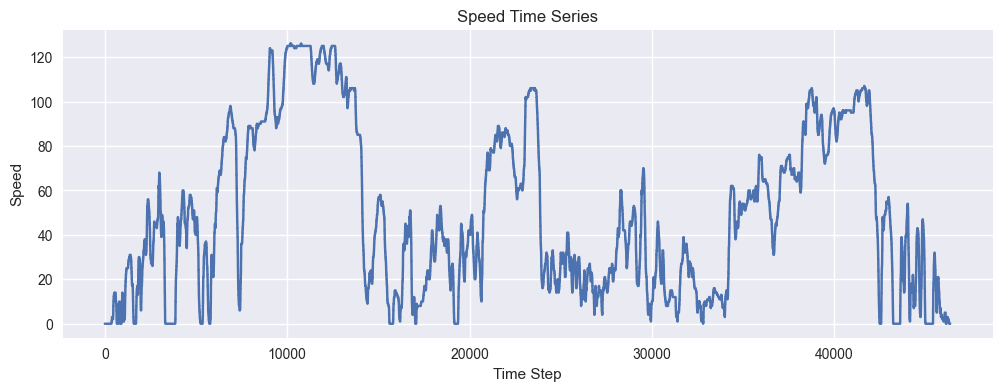

In [17]:
plt.figure(figsize=(12,4))
plt.plot(sample_trip["speed"])
plt.title("Speed Time Series")
plt.xlabel("Time Step")
plt.ylabel("Speed")
plt.show()

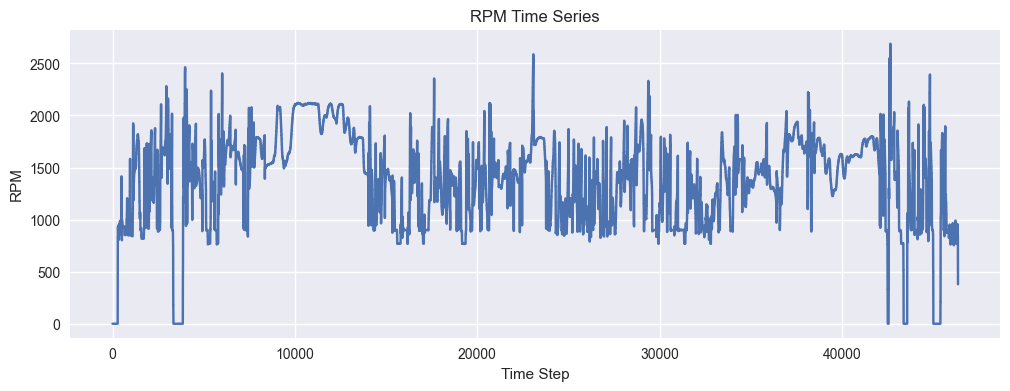

In [18]:
plt.figure(figsize=(12,4))
plt.plot(sample_trip["rpm"])
plt.title("RPM Time Series")
plt.xlabel("Time Step")
plt.ylabel("RPM")
plt.show()

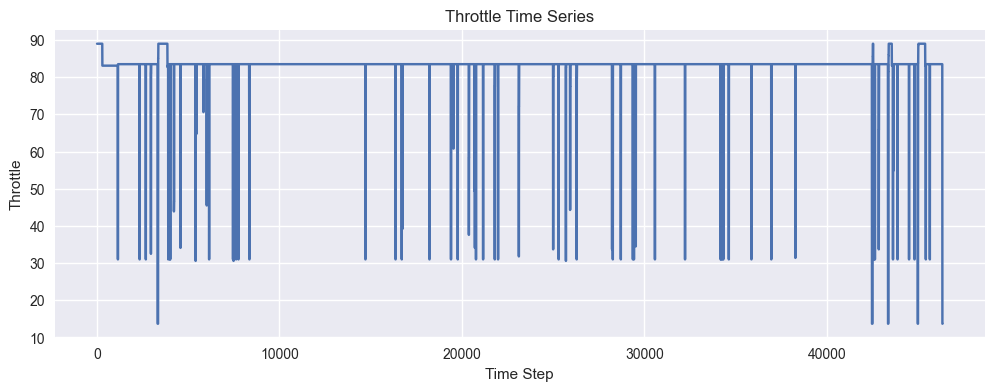

In [19]:
plt.figure(figsize=(12,4))
plt.plot(sample_trip["throttle"])
plt.title("Throttle Time Series")
plt.xlabel("Time Step")
plt.ylabel("Throttle")
plt.show()

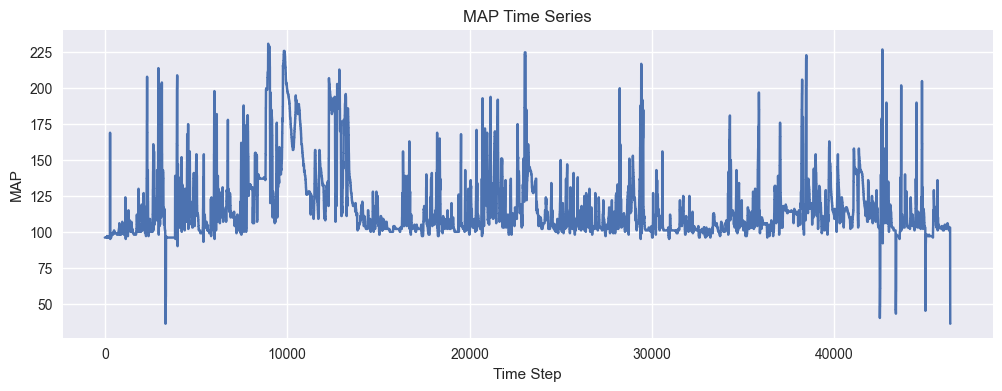

In [20]:
plt.figure(figsize=(12,4))
plt.plot(sample_trip["map"])
plt.title("MAP Time Series")
plt.xlabel("Time Step")
plt.ylabel("MAP")
plt.show()

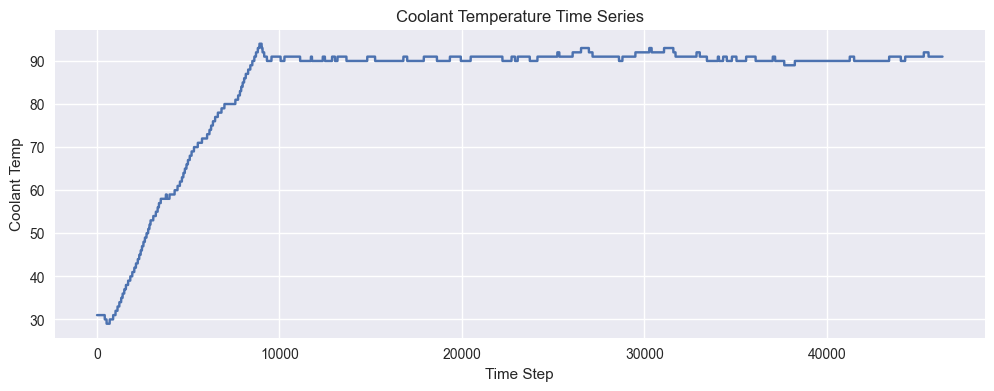

In [21]:
plt.figure(figsize=(12,4))
plt.plot(sample_trip["coolant_temp"])
plt.title("Coolant Temperature Time Series")
plt.xlabel("Time Step")
plt.ylabel("Coolant Temp")
plt.show()

## 4. Sensor Relationship Analysis

Inspect pairwise signal interactions linked to driver input and engine response.

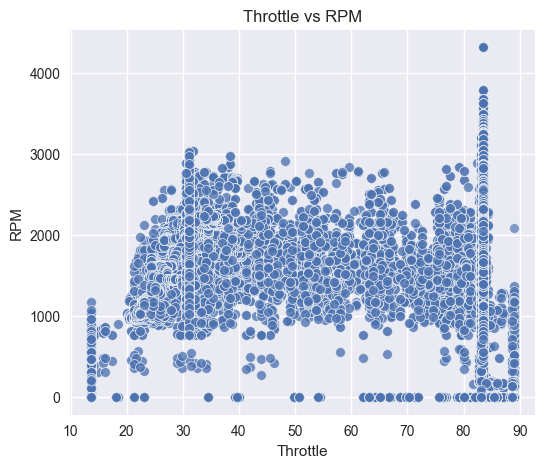

In [22]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df["throttle"], y=df["rpm"], alpha=0.3)
plt.title("Throttle vs RPM")
plt.xlabel("Throttle")
plt.ylabel("RPM")
plt.show()

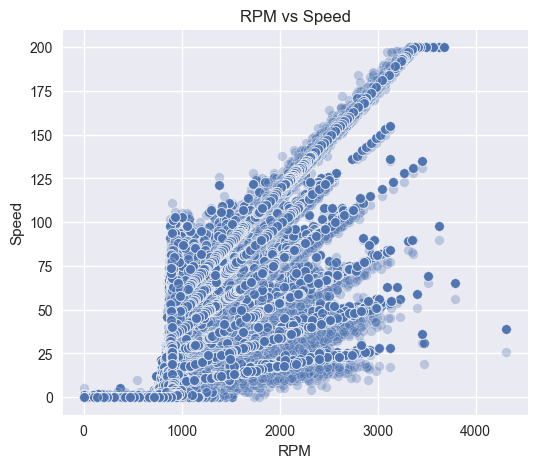

In [23]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df["rpm"], y=df["speed"], alpha=0.3)
plt.title("RPM vs Speed")
plt.xlabel("RPM")
plt.ylabel("Speed")
plt.show()

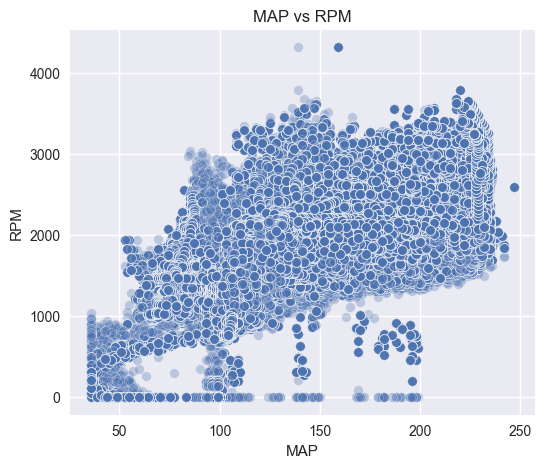

In [24]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df["map"], y=df["rpm"], alpha=0.3)
plt.title("MAP vs RPM")
plt.xlabel("MAP")
plt.ylabel("RPM")
plt.show()

## 5. Correlation Analysis

Quantify linear dependencies across numeric signals to inform feature relevance.

In [25]:
corr_matrix = df.corr(numeric_only=True)

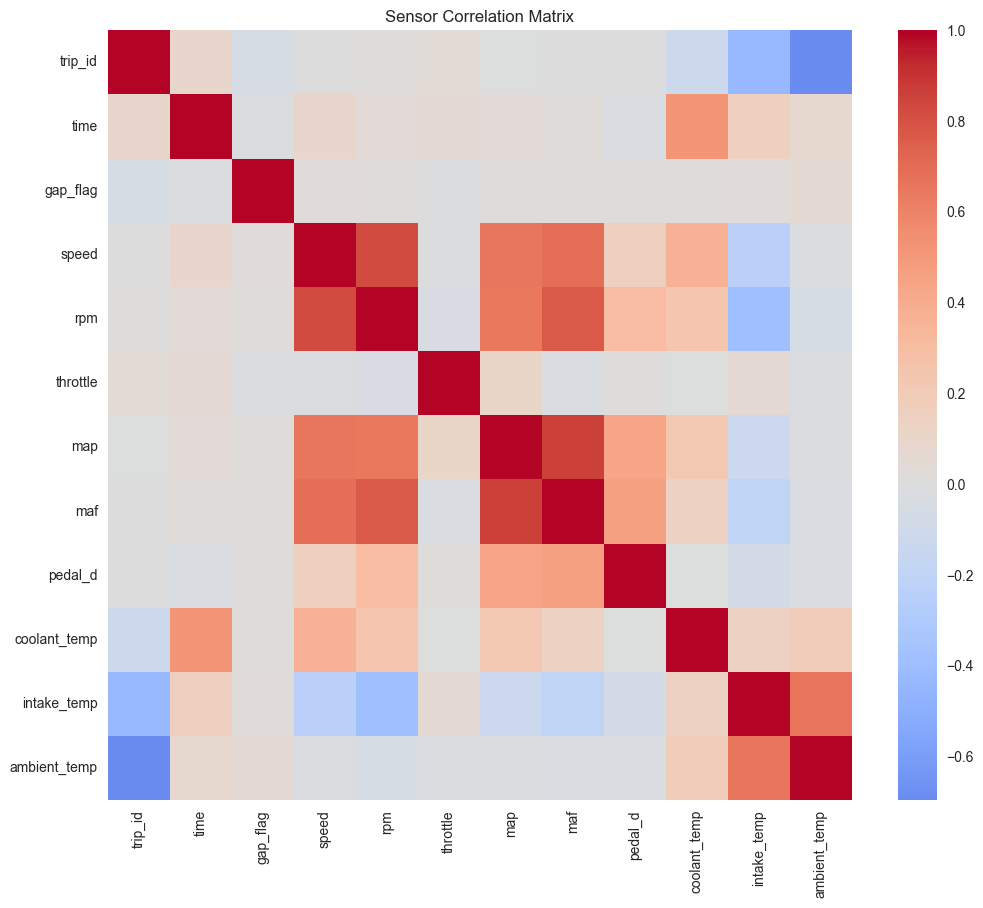

In [26]:
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Sensor Correlation Matrix")
plt.show()

## 6. Trip-Level Analysis

Compare aggregate trip behavior to capture variability across driving sessions.

In [27]:
trip_statistics = df.groupby("trip_id").agg(
{
    "speed":["mean","max"],
    "rpm":["mean","max"],
    "throttle":"mean",
    "map":"mean",
    "maf":"mean"
}
)

trip_statistics

speed                 rpm           throttle         map  \
              mean    max         mean     max       mean        mean   
trip_id                                                                 
1        49.567412  126.0  1378.098406  2689.0  82.741572  117.672096   
2        80.593504  198.0  1671.692248  3328.0  83.095976  138.492163   
3        25.087516  101.0  1052.105074  2979.0  81.922727  110.096516   
4        75.846740  182.0  1595.516882  3072.0  82.982038  133.696344   
5        60.412027  126.0  1441.696586  2501.0  82.755116  121.083325   
...            ...    ...          ...     ...        ...         ...   
77       69.805143  128.0  1515.704675  2737.0  82.875783  124.048208   
78       57.609995  128.0  1395.602973  2902.0  83.137560  121.538647   
79       51.927089  200.0  1334.188543  3430.0  83.032559  121.834191   
80       31.992578   86.0  1259.590867  2835.0  81.843738  115.684053   
81       57.174581  193.0  1428.732681  3255.0  82.855079  123.056903   

               maf  
              mean  
trip_id             
1        18.005956  
2        31.380198  
3        12.856620  
4        25.923130  
5        19.709988  
...            ...  
77       21.714781  
78       19.419223  
79       20.068405  
80       16.219101  
81       20.949461  

[81 rows x 7 columns]

## 7. Outlier Analysis

Inspect tails and spread of key variables for unusual operating regimes.

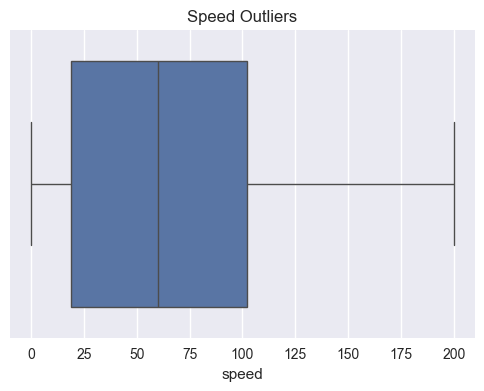

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["speed"])
plt.title("Speed Outliers")
plt.show()

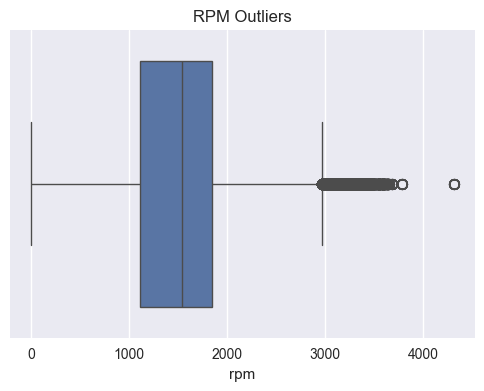

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["rpm"])
plt.title("RPM Outliers")
plt.show()

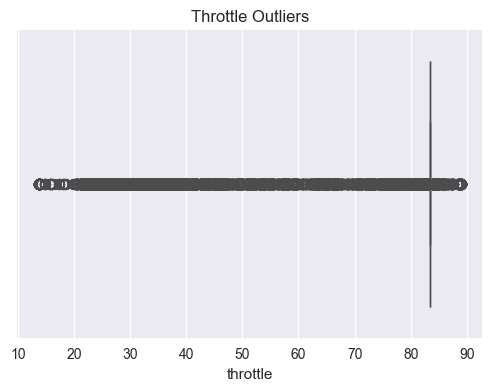

In [30]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["throttle"])
plt.title("Throttle Outliers")
plt.show()

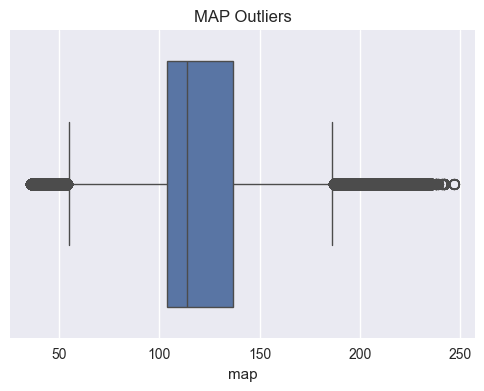

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["map"])
plt.title("MAP Outliers")
plt.show()

In [32]:
df.var(numeric_only=True).sort_values()

gap_flag        4.815066e-03
ambient_temp    1.267844e+02
throttle        1.279251e+02
pedal_d         1.597876e+02
maf             2.677266e+02
intake_temp     3.267666e+02
coolant_temp    3.273420e+02
trip_id         5.941113e+02
map             9.857007e+02
speed           2.096542e+03
rpm             2.863517e+05
time            2.108469e+06
dtype: float64

In [33]:
# Consistent visual style for the extended analysis
sns.set_theme(style="whitegrid", context="notebook")
FIG_SIZE_SMALL = (7, 4)
FIG_SIZE_MEDIUM = (10, 4)
FIG_SIZE_LARGE = (12, 5)
PLOT_ALPHA = 0.25

# Behavior frame sorted by trip and time
eda_df = df.sort_values(["trip_id", "time"]).copy()

# Temporal dynamics
eda_df["acceleration"] = eda_df.groupby("trip_id")["speed"].diff()
eda_df["jerk"] = eda_df.groupby("trip_id")["acceleration"].diff()

# Intent-response lag features (vehicle response at t+1)
eda_df["speed_lag1"] = eda_df.groupby("trip_id")["speed"].shift(-1)
eda_df["rpm_lag1"] = eda_df.groupby("trip_id")["rpm"].shift(-1)

# Window-level rolling behavior (window=5 samples)
eda_df["rolling_mean_speed"] = eda_df.groupby("trip_id")["speed"].transform(lambda s: s.rolling(window=5, min_periods=2).mean())
eda_df["rolling_std_speed"] = eda_df.groupby("trip_id")["speed"].transform(lambda s: s.rolling(window=5, min_periods=2).std())

print("Extended EDA frame shape:", eda_df.shape)
eda_df[["trip_id", "time", "speed", "acceleration", "jerk", "speed_lag1", "rpm_lag1", "rolling_std_speed"]].head()

Extended EDA frame shape: (2693824, 18)


,trip_id,time,speed,acceleration,jerk,speed_lag1,rpm_lag1,rolling_std_speed
0,1,0.000,0.0,NaN,NaN,0.0,0.0,NaN
1,1,0.091,0.0,0.0,NaN,0.0,0.0,0.0
2,1,0.181,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0.272,0.0,0.0,0.0,0.0,0.0,0.0
4,1,0.370,0.0,0.0,0.0,0.0,0.0,0.0


## 8. Behavior-Aware EDA Extensions

This section extends baseline EDA with temporal, lagged, and window-aware analyses aligned to the feature pipeline in Notebook 03.

### Extension Rationale

The following subsections are exploratory and observational only. They are designed to justify representation choices for downstream feature engineering without introducing labels or decision rules.

### 8.1 Temporal Dynamics

Acceleration and jerk characterize short-horizon driving smoothness and abruptness.

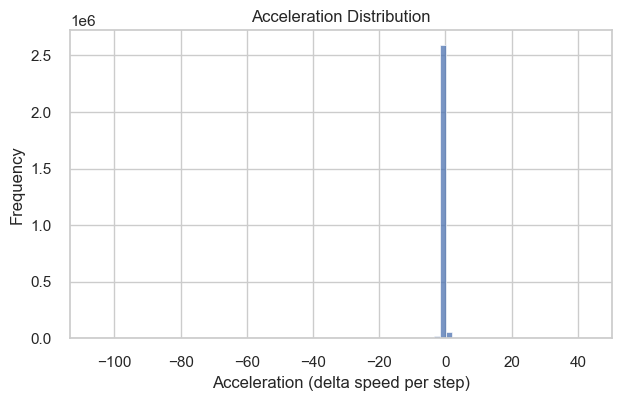

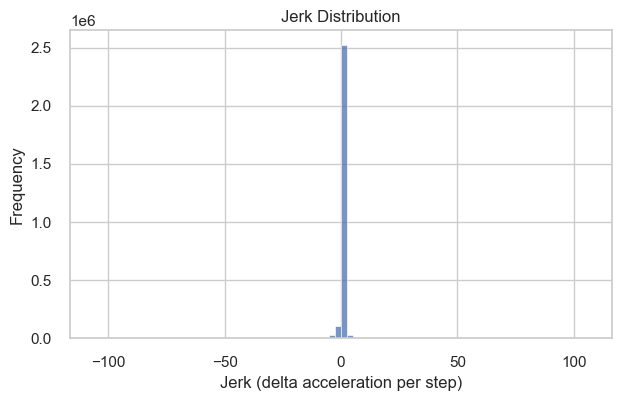

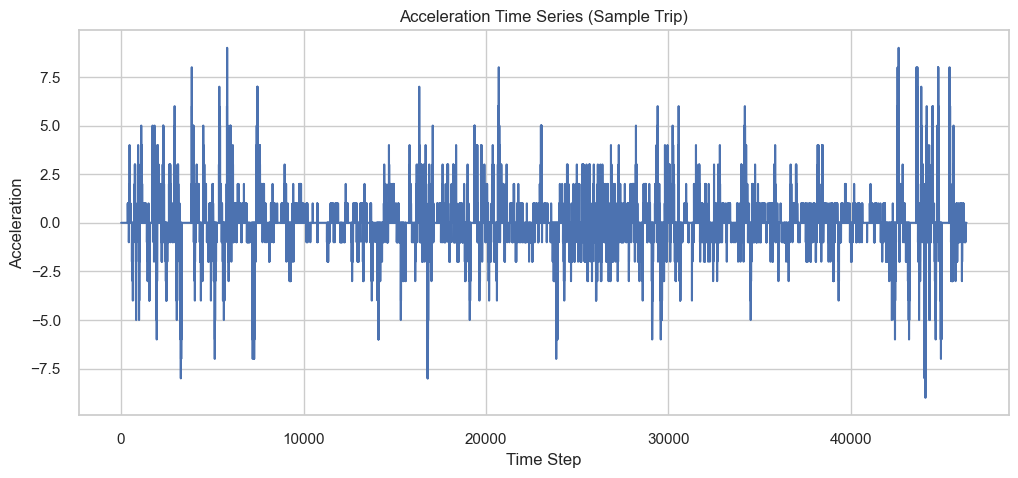

In [34]:
plt.figure(figsize=FIG_SIZE_SMALL)
sns.histplot(eda_df["acceleration"].dropna(), bins=80)
plt.title("Acceleration Distribution")
plt.xlabel("Acceleration (delta speed per step)")
plt.ylabel("Frequency")
plt.show()
# Observation: Heavy tails in acceleration indicate intermittent sharp speed changes.

plt.figure(figsize=FIG_SIZE_SMALL)
sns.histplot(eda_df["jerk"].dropna(), bins=80)
plt.title("Jerk Distribution")
plt.xlabel("Jerk (delta acceleration per step)")
plt.ylabel("Frequency")
plt.show()
# Observation: Jerk variability highlights abrupt transitions beyond average acceleration levels.

sample_trip_dyn = eda_df[eda_df["trip_id"] == trip_id]
plt.figure(figsize=FIG_SIZE_LARGE)
plt.plot(sample_trip_dyn["acceleration"].values)
plt.title("Acceleration Time Series (Sample Trip)")
plt.xlabel("Time Step")
plt.ylabel("Acceleration")
plt.show()
# Observation: Local acceleration bursts and reversals support temporal window-based modeling.

### 8.2 Intent–Response Analysis

Lag relationships inspect how throttle input maps to near-future speed and RPM response.

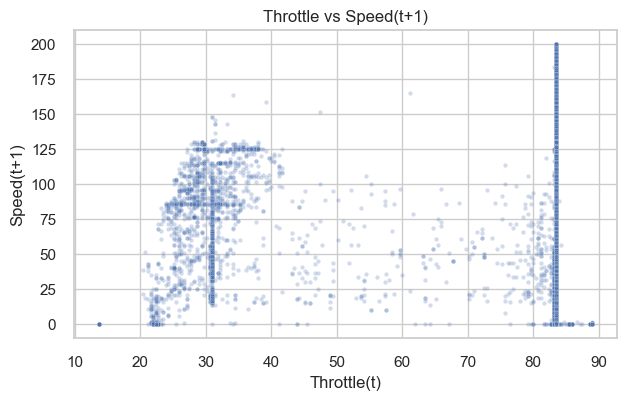

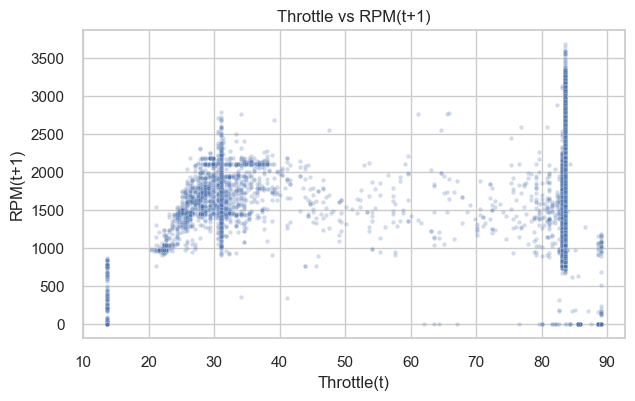

In [35]:
lag_source = eda_df.dropna(subset=["throttle", "speed_lag1", "rpm_lag1"])
lag_sample = lag_source.sample(
    n=min(50000, len(lag_source)),
    random_state=42
)

plt.figure(figsize=FIG_SIZE_SMALL)
sns.scatterplot(data=lag_sample, x="throttle", y="speed_lag1", alpha=PLOT_ALPHA, s=10)
plt.title("Throttle vs Speed(t+1)")
plt.xlabel("Throttle(t)")
plt.ylabel("Speed(t+1)")
plt.show()
# Observation: Positive trend suggests throttle input contributes to next-step speed response.

plt.figure(figsize=FIG_SIZE_SMALL)
sns.scatterplot(data=lag_sample, x="throttle", y="rpm_lag1", alpha=PLOT_ALPHA, s=10)
plt.title("Throttle vs RPM(t+1)")
plt.xlabel("Throttle(t)")
plt.ylabel("RPM(t+1)")
plt.show()
# Observation: Throttle-to-RPM coupling is visible but dispersed, indicating context-dependent response.

### 8.3 Window-Level Behavior

Rolling-window statistics approximate the local behavior representation used in feature engineering.

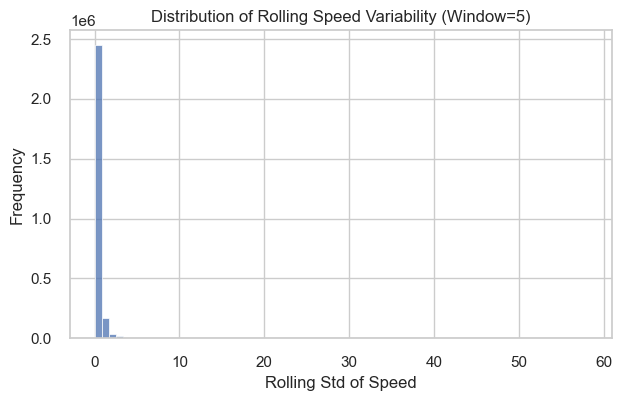

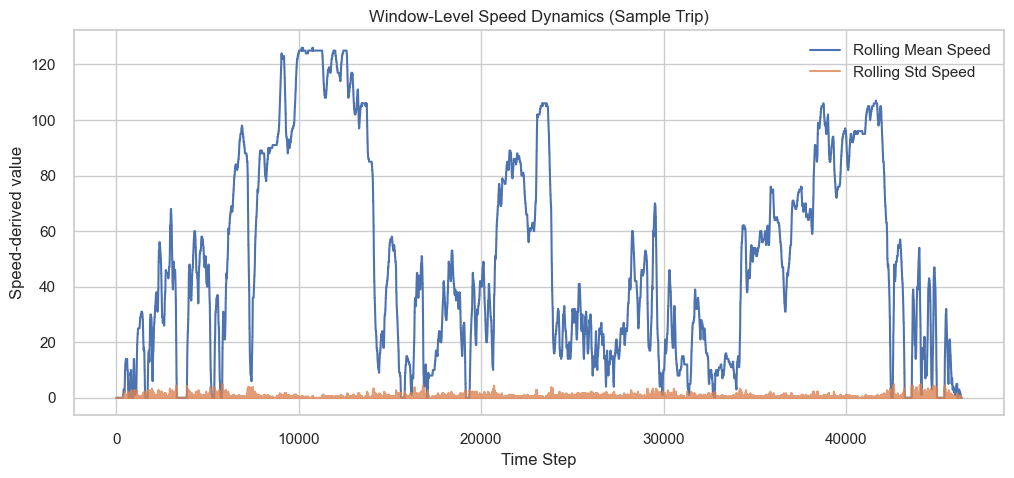

In [36]:
plt.figure(figsize=FIG_SIZE_SMALL)
sns.histplot(eda_df["rolling_std_speed"].dropna(), bins=70)
plt.title("Distribution of Rolling Speed Variability (Window=5)")
plt.xlabel("Rolling Std of Speed")
plt.ylabel("Frequency")
plt.show()
# Observation: Broad rolling-std spread indicates meaningful intra-trip variability.

sample_trip_roll = eda_df[eda_df["trip_id"] == trip_id]
plt.figure(figsize=FIG_SIZE_LARGE)
plt.plot(sample_trip_roll["rolling_mean_speed"].values, label="Rolling Mean Speed")
plt.plot(sample_trip_roll["rolling_std_speed"].values, label="Rolling Std Speed", alpha=0.8)
plt.title("Window-Level Speed Dynamics (Sample Trip)")
plt.xlabel("Time Step")
plt.ylabel("Speed-derived value")
plt.legend()
plt.show()
# Observation: Window-level variation changes over time, motivating segment-based modeling.

### 8.4 Driver Variability Across Trips

Trip distributions reveal heterogeneity in typical driving pace and engine operating regime.

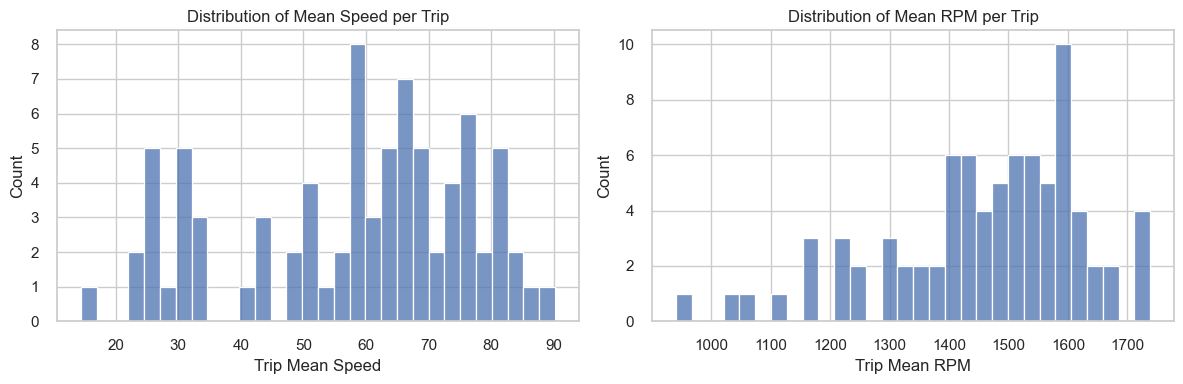

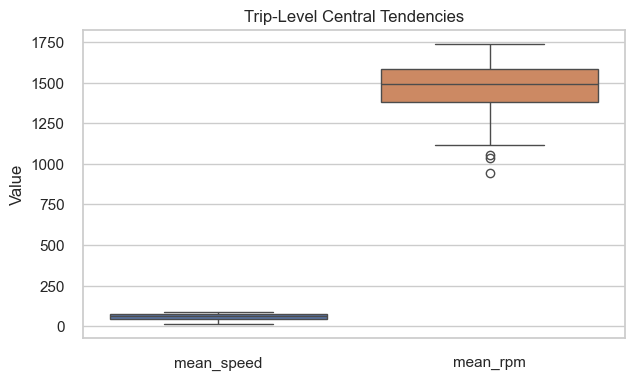

In [37]:
trip_behavior = eda_df.groupby("trip_id").agg(
    mean_speed=("speed", "mean"),
    mean_rpm=("rpm", "mean"),
    std_speed=("speed", "std"),
    std_throttle=("throttle", "std")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(trip_behavior["mean_speed"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of Mean Speed per Trip")
axes[0].set_xlabel("Trip Mean Speed")

sns.histplot(trip_behavior["mean_rpm"], bins=30, ax=axes[1])
axes[1].set_title("Distribution of Mean RPM per Trip")
axes[1].set_xlabel("Trip Mean RPM")
plt.tight_layout()
plt.show()
# Observation: Trip-level central tendencies vary substantially across sessions.

plt.figure(figsize=FIG_SIZE_SMALL)
sns.boxplot(data=trip_behavior[["mean_speed", "mean_rpm"]])
plt.title("Trip-Level Central Tendencies")
plt.ylabel("Value")
plt.show()
# Observation: Distribution spread supports modeling multiple driving contexts.

### 8.5 Event-Like Analysis from Extremes

Acceleration tails reveal high-intensity maneuvers without defining any class labels.

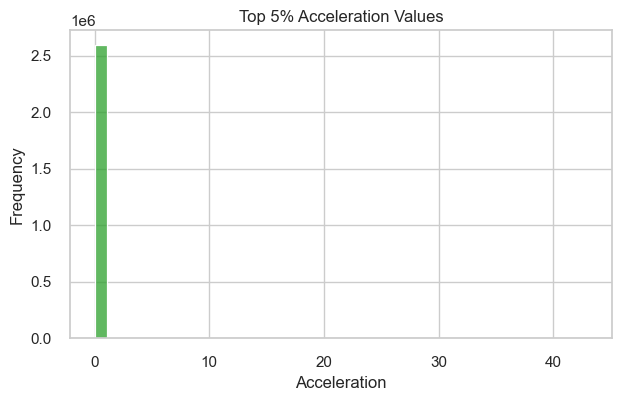

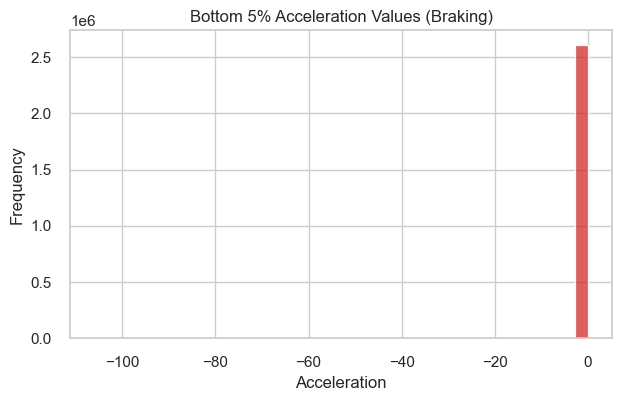

In [38]:
acc_valid = eda_df["acceleration"].dropna()
acc_q95 = acc_valid.quantile(0.95)
acc_q05 = acc_valid.quantile(0.05)

extreme_acc = acc_valid[acc_valid >= acc_q95]
extreme_brake = acc_valid[acc_valid <= acc_q05]

plt.figure(figsize=FIG_SIZE_SMALL)
sns.histplot(extreme_acc, bins=40, color="tab:green")
plt.title("Top 5% Acceleration Values")
plt.xlabel("Acceleration")
plt.ylabel("Frequency")
plt.show()
# Observation: Upper-tail acceleration confirms burst-like driving episodes.

plt.figure(figsize=FIG_SIZE_SMALL)
sns.histplot(extreme_brake, bins=40, color="tab:red")
plt.title("Bottom 5% Acceleration Values (Braking)")
plt.xlabel("Acceleration")
plt.ylabel("Frequency")
plt.show()
# Observation: Lower-tail acceleration indicates sharp deceleration regimes are present.

### 8.6 Feature Relevance Insight

Behavior-relevant correlation views connect EDA evidence to feature family design.

corr(speed, rpm) = 0.8257
corr(throttle, rpm) = -0.0381
corr(map, rpm) = 0.6503


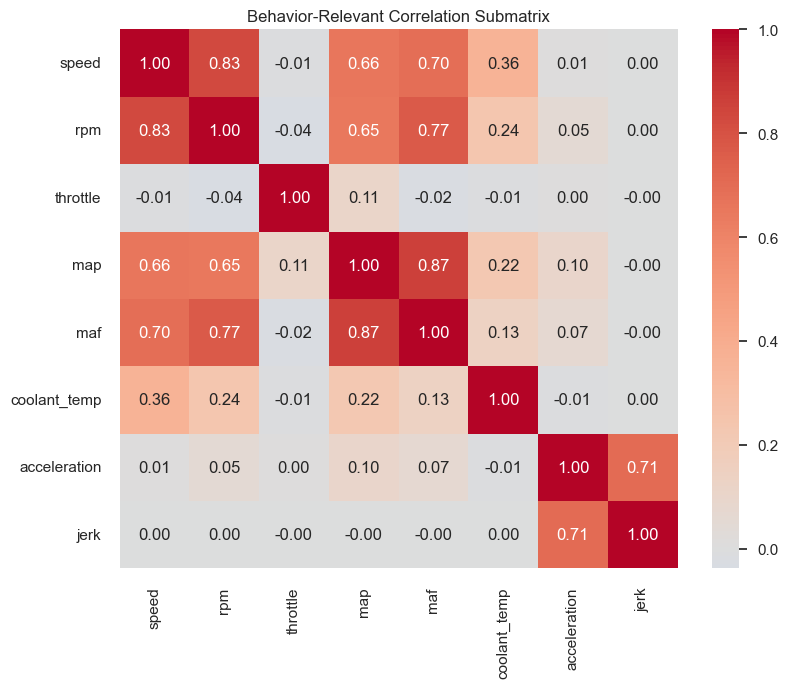

In [39]:
key_pairs = [("speed", "rpm"), ("throttle", "rpm"), ("map", "rpm")]
for a, b in key_pairs:
    c = corr_matrix.loc[a, b]
    print(f"corr({a}, {b}) = {c:.4f}")

subset_cols = ["speed", "rpm", "throttle", "map", "maf", "coolant_temp", "acceleration", "jerk"]
subset_corr = eda_df[subset_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(subset_corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Behavior-Relevant Correlation Submatrix")
plt.show()
# Observation: Core engine-response pairs remain strongly coupled and justify relational features.

### 8.7 Multi-Signal Interaction

Sampled joint views help inspect nonlinear coupling between input controls and vehicle response.

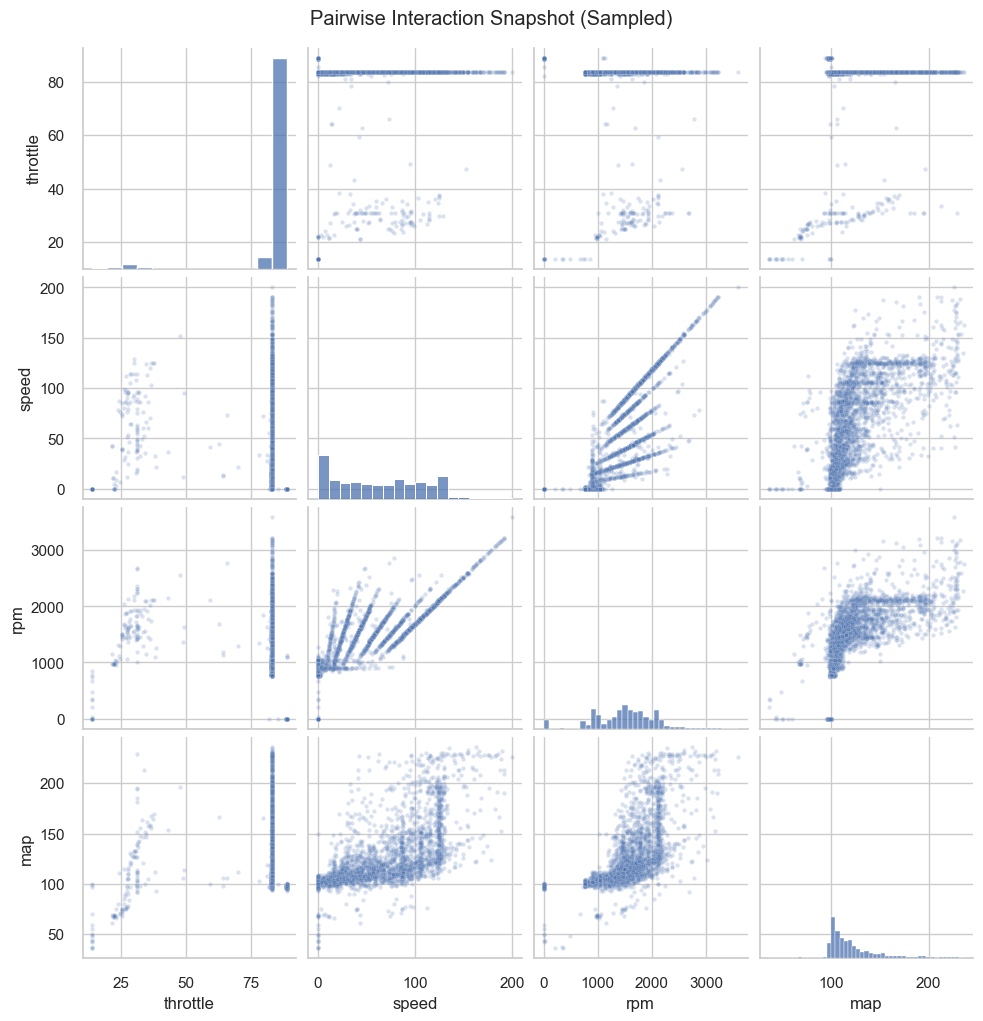

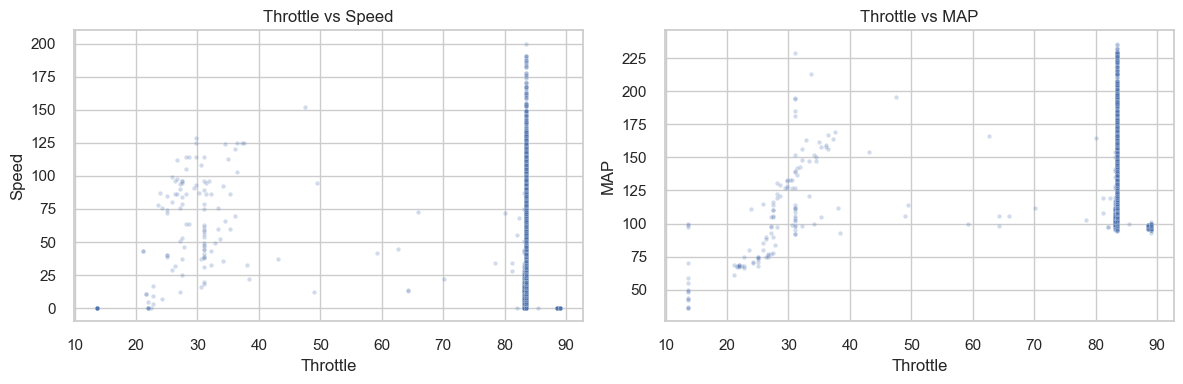

In [40]:
interaction_cols = ["throttle", "speed", "rpm", "map", "acceleration"]
interaction_df = eda_df[interaction_cols].dropna()
interaction_sample = interaction_df.sample(n=min(3000, len(interaction_df)), random_state=42)

sns.pairplot(
    interaction_sample,
    vars=["throttle", "speed", "rpm", "map"],
    plot_kws={"alpha": 0.2, "s": 10}
)
plt.suptitle("Pairwise Interaction Snapshot (Sampled)", y=1.02)
plt.show()
# Observation: Pairwise structure suggests nonlinear signal coupling across driving states.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=interaction_sample, x="throttle", y="speed", alpha=PLOT_ALPHA, s=10, ax=axes[0])
axes[0].set_title("Throttle vs Speed")
axes[0].set_xlabel("Throttle")
axes[0].set_ylabel("Speed")

sns.scatterplot(data=interaction_sample, x="throttle", y="map", alpha=PLOT_ALPHA, s=10, ax=axes[1])
axes[1].set_title("Throttle vs MAP")
axes[1].set_xlabel("Throttle")
axes[1].set_ylabel("MAP")
plt.tight_layout()
plt.show()
# Observation: Input-output spread indicates context-dependent response gain rather than a single linear regime.

## EDA Summary Table

Compact statistical view of behavior-critical variables used in downstream feature engineering.

In [41]:
eda_summary = eda_df[[
    "speed",
    "acceleration",
    "jerk",
    "rolling_std_speed"
]].describe()

eda_summary

,speed,acceleration,jerk,rolling_std_speed
count,2.693824e+06,2.693743e+06,2.693662e+06,2.693743e+06
mean,6.224243e+01,-3.638060e-05,0.000000e+00,2.034521e-01
std,4.578801e+01,5.872011e-01,8.304644e-01,5.507765e-01
min,0.000000e+00,-1.060000e+02,-1.060000e+02,0.000000e+00
25%,1.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.020000e+02,0.000000e+00,0.000000e+00,0.000000e+00
max,2.000000e+02,4.300000e+01,1.060000e+02,5.805859e+01


## Final Observations (Research Summary)

Driving behavior in this dataset is temporally rich and nonstationary; acceleration and jerk expose micro-dynamics that are not visible in raw speed alone.

Lag analysis shows measurable throttle-to-response coupling for speed and RPM at the next step, supporting intent-response feature design in Notebook 03.

Window-level variability confirms that overlapping short-horizon segments are necessary to represent local behavior changes robustly.

Trip-level heterogeneity indicates multiple operating regimes across sessions, motivating context discovery and unsupervised analysis.

Acceleration tails and multi-signal interaction plots reveal high-intensity episodes and nonlinear coupling, supporting a rich feature space for anomaly detection and sequence modeling.

Overall, this EDA provides direct empirical justification for the temporal, relational, and variability-focused feature families used in Notebook 03.